# GNN Validation Experiment — Plug-and-Play Architecture Testing

**Goal:** Verify that each GNN architecture (a) converges and (b) actually exploits the EU trade network topology, rather than just memorising node features.

## Pipeline overview
| Stage | Description |
|---|---|
| **Data** | Same cleaned CSVs as before — no imputation needed |
| **Stability setup** | `log1p / 25.0` target scaling · manual self-loops · gradient clipping |
| **Model** | `PlugAndPlayGNN`: Linear encoder → 2-layer GNN backbone → link-predictor MLP |
| **Phase 1a Stability test** | 50 epochs, fixed LR — loss must decrease, predictions must not collapse |
| **Phase 1b Topology test** | Same model trained on shuffled edge_index — real graph must beat shuffled |
| **Sweep** | `[GCNConv, GATv2Conv, SAGEConv, TransformerConv]` |


In [1]:
# =========================================================
# Cell A — Imports & Configuration
# =========================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

try:
    from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv
    HAS_PYG = True
    print("✓ PyTorch Geometric available")
except ImportError:
    HAS_PYG = False
    print("✗ PyTorch Geometric not found — run: pip install torch-geometric")

warnings.filterwarnings("ignore", category=UserWarning)

# ---------------------------------------------------------
# Canonical configuration (must match the pipeline)
# ---------------------------------------------------------

START_MONTH = "2014-01"
END_MONTH   = "2025-11"

MONTHLY_IDX = pd.date_range(START_MONTH, END_MONTH, freq="MS")

COUNTRIES = [
    "AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE", "EL",
    "ES", "FI", "FR", "HR", "HU", "IE", "IT", "LT", "LU",
    "LV", "MT", "NL", "PL", "PT", "RO", "SE", "SI", "SK",
]

COUNTRY_IDX = {c: i for i, c in enumerate(COUNTRIES)}
N = len(COUNTRIES)  # 27

ALL_CATS = [
    "TOTAL",
    "Food_drinks_tobacco",
    "Raw_materials",
    "Energy",
    "Chemicals",
    "Machinery_vehicles",
    "Other_manufactured",
]

N_CATS = len(ALL_CATS)  # 7

CEPII_COLS = [
    "comlang_ethno",
    "contig",
    "smctry",
    "dist",
    "distcap",
    "distw",
    "distwces",
]

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

DATA_DIR = Path(
    "C:/Users/diede/Downloads/FILES FROM FULL DATA PIPELINE RUN"
)

MAIN_DATA_DIR = DATA_DIR / "main_data"
NODE_DIR      = DATA_DIR / "NodeFeatures" / "Second Try"
EDGE_DIR      = DATA_DIR / "edge_features"
GRAPH_DIR     = DATA_DIR / "graph_features"

IMPUTED_TRADE_CSV = MAIN_DATA_DIR / "eu_intra_trade_sitc_imputed.csv"

# ---------------------------------------------------------
# Experiment hyperparameters
# ---------------------------------------------------------

HIDDEN_DIM = 64       # node embedding dimension
N_EPOCHS   = 50       # epochs per validation run
LR         = 3e-4     # fixed learning rate
GRAD_CLIP  = 1.0      # gradient norm cap

# TARGET_SCALE computed later (Cell D)

HEADS   = 4
SEED    = 42
SEQ_LEN = 6           # temporal window length

LOG_NODE_FEATURES = True  # log1p before z-score

TRAIN_END = pd.Timestamp("2022-12-01")
VAL_END   = pd.Timestamp("2023-12-01")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device        : {DEVICE}")
print(f"Monthly index: {MONTHLY_IDX[0].date()} → {MONTHLY_IDX[-1].date()} ({len(MONTHLY_IDX)} periods)")
print(f"Countries    : {N} | Categories: {N_CATS} | Directed edges: {N*(N-1)}")
print(f"SEQ_LEN: {SEQ_LEN} | LOG_NODE_FEATURES: {LOG_NODE_FEATURES}")

c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 

✓ PyTorch Geometric available
Device        : cpu
Monthly index: 2014-01-01 → 2025-11-01 (143 periods)
Countries    : 27 | Categories: 7 | Directed edges: 702
SEQ_LEN: 6 | LOG_NODE_FEATURES: True


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell B — Load All CSVs
# Data is already fully clean — no imputation needed.
# ══════════════════════════════════════════════════════════════════════════════

# ── B.1 Trade CSV ─────────────────────────────────────────────────────────────
df_trade = pd.read_csv(IMPUTED_TRADE_CSV)
df_trade["time"] = pd.to_datetime(df_trade["time"])
print(f"── Trade CSV ──")
print(f"  Shape      : {df_trade.shape}")
print(f"  Time range : {df_trade['time'].min().date()} → {df_trade['time'].max().date()}")
print(f"  Reporters  : {sorted(df_trade['reporter'].unique())}")
assert df_trade.isna().sum().sum() == 0, "NaNs in trade CSV!"
print(f"  NaNs       : 0 ✓\n")

# ── B.2 Node feature CSVs (T × 27 each) ──────────────────────────────────────
node_csv_paths = sorted(NODE_DIR.glob("*.csv"))
assert node_csv_paths, f"No node CSVs found in {NODE_DIR}"

node_dfs = {}   # stem → DataFrame(T, 27)
for p in node_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    node_dfs[p.stem] = df

total_node_nans = sum(df.isna().sum().sum() for df in node_dfs.values())
print(f"── Node feature CSVs ──")
print(f"  Files loaded : {len(node_dfs)}")
print(f"  Total NaNs   : {total_node_nans}")
assert total_node_nans == 0, f"Found {total_node_nans} NaNs in node features!"
print(f"  ✓ All clean\n")

# ── B.3 Graph feature CSVs (EURIBOR, VSTOXX — broadcast to all 27 cols) ──────
graph_csv_paths = sorted(GRAPH_DIR.glob("*.csv"))
graph_series = {}   # stem → Series(T,)

for p in graph_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    assert df.std(axis=1).max() < 1e-9, f"{p.name}: columns are not identical broadcasts!"
    graph_series[p.stem] = df.iloc[:, 0].rename(p.stem)

print(f"── Graph feature CSVs ──")
print(f"  Files loaded : {len(graph_series)}  → {list(graph_series.keys())}\n")

# ── B.4 Edge feature CSV (CEPII bilateral static) ─────────────────────────────
edge_csv = EDGE_DIR / "eu27_bilateral_static_features.csv"
assert edge_csv.exists(), f"Edge feature CSV not found at {edge_csv}"
df_edge = pd.read_csv(edge_csv)
df_edge["time"] = pd.to_datetime(df_edge["time"])
print(f"── Edge feature CSV ──")
print(f"  Shape  : {df_edge.shape}")
print(f"  Cols   : {list(df_edge.columns)}")

── Trade CSV ──
  Shape      : (100262, 10)
  Time range : 2014-01-01 → 2025-11-01
  Reporters  : ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
  NaNs       : 0 ✓

── Node feature CSVs ──
  Files loaded : 35
  Total NaNs   : 0
  ✓ All clean

── Graph feature CSVs ──
  Files loaded : 2  → ['euribor3m_monthly', 'vstoxx_monthly']

── Edge feature CSV ──
  Shape  : (100386, 11)
  Cols   : ['Unnamed: 0', 'time', 'reporter', 'partner', 'comlang_ethno', 'contig', 'smctry', 'dist', 'distcap', 'distw', 'distwces']


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell C — Tensor Assembly
# ══════════════════════════════════════════════════════════════════════════════

# ── C.1 Align all sources to a common monthly index ───────────────────────────
common_time = MONTHLY_IDX
for stem, df in node_dfs.items():
    common_time = common_time.intersection(df.index)
for stem, s in graph_series.items():
    common_time = common_time.intersection(s.index)
trade_times = pd.DatetimeIndex(sorted(df_trade["time"].unique()))
common_time = common_time.intersection(trade_times)
T = len(common_time)
print(f"Common time range: {common_time[0].date()} → {common_time[-1].date()}  (T={T})")

# ── C.2 Node feature tensor (T, N, F_node) ────────────────────────────────────
node_arrays, node_feat_names = [], []
for stem, df in sorted(node_dfs.items()):
    arr = df.loc[common_time, COUNTRIES].values.astype(np.float32)   # (T, N)
    node_arrays.append(arr)
    node_feat_names.append(stem)
node_np = np.stack(node_arrays, axis=-1)   # (T, N, F_node)
F_node  = node_np.shape[2]

# ── C.3 Graph feature tensor → broadcast to all nodes ────────────────────────
graph_feat_names = sorted(graph_series.keys())
graph_np = np.stack(
    [graph_series[s].reindex(common_time).values.astype(np.float32) for s in graph_feat_names],
    axis=-1,
)   # (T, F_graph)
graph_broadcast    = np.repeat(graph_np[:, np.newaxis, :], N, axis=1)    # (T, N, F_graph)
node_plus_graph_np = np.concatenate([node_np, graph_broadcast], axis=-1)  # (T, N, F_total)
F_total = node_plus_graph_np.shape[2]

# ── C.4 Target tensor (T, E, C) ───────────────────────────────────────────────
edge_pairs = [(i, j) for i in range(N) for j in range(N) if i != j]   # 702 directed edges
E      = len(edge_pairs)
src_idx = [p[0] for p in edge_pairs]
dst_idx = [p[1] for p in edge_pairs]

target_np = np.full((T, N, N, N_CATS), np.nan, dtype=np.float32)
for t_idx, ts in enumerate(common_time):
    df_t = df_trade[df_trade["time"] == ts]
    for _, row in df_t.iterrows():
        ri = COUNTRY_IDX.get(row["reporter"])
        pi = COUNTRY_IDX.get(row["partner"])
        if ri is not None and pi is not None and ri != pi:
            target_np[t_idx, ri, pi, :] = [row[c] for c in ALL_CATS]

target_edge_np = target_np[:, src_idx, dst_idx, :]   # (T, E, C)

# ── C.5 Static edge features (E, F_edge) ──────────────────────────────────────
F_edge = len(CEPII_COLS)
df_edge_t0   = df_edge[df_edge["time"] == df_edge["time"].min()].copy()
edge_feat_map = {}
for _, row in df_edge_t0.iterrows():
    ri = COUNTRY_IDX.get(row["reporter"])
    pi = COUNTRY_IDX.get(row["partner"])
    if ri is not None and pi is not None and ri != pi:
        edge_feat_map[(ri, pi)] = [row[c] for c in CEPII_COLS]

edge_feat_np = np.zeros((E, F_edge), dtype=np.float32)
for e_idx, (i, j) in enumerate(edge_pairs):
    if (i, j) in edge_feat_map:
        edge_feat_np[e_idx] = edge_feat_map[(i, j)]

# ── C.6 Convert to tensors ────────────────────────────────────────────────────
node_feat_tensor = torch.tensor(node_plus_graph_np, dtype=torch.float32)   # (T, N, F_total)
edge_feat_tensor = torch.tensor(edge_feat_np,       dtype=torch.float32)   # (E, F_edge)
target_tensor    = torch.tensor(target_edge_np,     dtype=torch.float32)   # (T, E, C)

print(f"\n✓ Tensor assembly complete")
print(f"  node_feat_tensor : {node_feat_tensor.shape}  (T, N, F_total={F_total})")
print(f"  edge_feat_tensor : {edge_feat_tensor.shape}  (E={E}, F_edge={F_edge})")
print(f"  target_tensor    : {target_tensor.shape}  (T, E, C={N_CATS})")
print(f"  NaNs in node features: {torch.isnan(node_feat_tensor).sum().item()}")
print(f"  NaNs in targets      : {torch.isnan(target_tensor).sum().item()}")

Common time range: 2014-01-01 → 2025-11-01  (T=143)

✓ Tensor assembly complete
  node_feat_tensor : torch.Size([143, 27, 37])  (T, N, F_total=37)
  edge_feat_tensor : torch.Size([702, 7])  (E=702, F_edge=7)
  target_tensor    : torch.Size([143, 702, 7])  (T, E, C=7)
  NaNs in node features: 0
  NaNs in targets      : 868


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell D — Temporal Split + Normalization  (v4)
#
# Changes from v3:
#  • Node features: per-node per-feature z-score (not pooled across all nodes)
#  • Node features: optional log1p of strictly-positive features before z-score
#  • Edge distances: log1p before min-max (dist, distcap, distw, distwces)
#  • TARGET_SCALE: computed as 99th-percentile of log1p(train targets), not hardcoded
#  • detransform() helper added for converting predictions back to EUR
# ══════════════════════════════════════════════════════════════════════════════

# ── D.1 Strict temporal split on TARGET timestamp ─────────────────────────────
train_idx = [t for t in range(len(common_time) - 1) if common_time[t + 1] <= TRAIN_END]
val_idx   = [t for t in range(len(common_time) - 1) if TRAIN_END < common_time[t + 1] <= VAL_END]
test_idx  = [t for t in range(len(common_time) - 1) if common_time[t + 1] > VAL_END]

print('=== Temporal Split (target-based) ===')
print(f'Train : {len(train_idx):3d} steps  targets up to {common_time[train_idx[-1]+1].date()}')
print(f'Val   : {len(val_idx):3d} steps  targets {common_time[val_idx[0]+1].date()} → {common_time[val_idx[-1]+1].date()}')
print(f'Test  : {len(test_idx):3d} steps  targets from {common_time[test_idx[0]+1].date()}')
assert common_time[train_idx[-1] + 1] <= TRAIN_END, 'Boundary leak: last train target in val'
assert common_time[val_idx[0]   + 1] >  TRAIN_END, 'Boundary leak: first val target in train'
print('✓ No boundary leak')

# ── D.2 Optional log-transform of node features ───────────────────────────────
# Only applies log1p to features whose minimum value in the training set is > 0.
# Features that can be zero or negative (e.g. bond yields, CPI changes) are left
# in levels — log is undefined or misleading for them.
if LOG_NODE_FEATURES:
    train_min_per_feat = (
        node_feat_tensor[train_idx]
        .reshape(-1, F_total)
        .min(dim=0).values
    )   # (F,)
    log_mask = (train_min_per_feat > 0)   # True → safe to log
    node_feat_raw = node_feat_tensor.clone()
    node_feat_raw[:, :, log_mask] = torch.log1p(node_feat_tensor[:, :, log_mask])
    print(f'Log-transforming {log_mask.sum().item()}/{F_total} strictly-positive node features')
else:
    node_feat_raw = node_feat_tensor
    log_mask      = None
    print('No log transform applied to node features')

# ── D.3 Per-node, per-feature z-score normalization ───────────────────────────
# Mean and std are computed per (country, feature) over training timesteps only.
# This preserves the different scales across countries (Malta vs Germany) and
# across features (GDP vs bond yield), unlike pooling all nodes into one stat.
train_data = node_feat_raw[train_idx]        # (T_train, N, F)
feat_mean  = train_data.mean(dim=0)          # (N, F)
feat_std   = train_data.std(dim=0).clamp(min=1e-8)   # (N, F)
node_feat_norm = (node_feat_raw - feat_mean) / feat_std   # (T, N, F)  broadcast over T

print(f'Node feat mean shape: {feat_mean.shape}  (per-node per-feature)')
print(f'NaNs after node norm : {torch.isnan(node_feat_norm).sum().item()}')

# ── D.4 Edge feature processing: log1p distances → min-max ───────────────────
# Distance features span multiple orders of magnitude across EU pairs.
# log1p compresses the tail before min-max, making the normalization more uniform.
# Binary/similarity features (comlang, contig, smctry) are left as-is.
DISTANCE_FEAT_COLS    = ['dist', 'distcap', 'distw', 'distwces']
SIMILARITY_FEAT_COLS  = ['comlang_ethno', 'contig', 'smctry']
DISTANCE_FEAT_INDICES = [CEPII_COLS.index(c) for c in DISTANCE_FEAT_COLS]
SIMILARITY_FEAT_INDICES = [CEPII_COLS.index(c) for c in SIMILARITY_FEAT_COLS]

edge_feat_proc = edge_feat_tensor.clone()
for col_idx in DISTANCE_FEAT_INDICES:
    edge_feat_proc[:, col_idx] = torch.log1p(edge_feat_proc[:, col_idx])

edge_feat_min   = edge_feat_proc.min(dim=0).values
edge_feat_max   = edge_feat_proc.max(dim=0).values
edge_feat_range = (edge_feat_max - edge_feat_min).clamp(min=1e-8)
edge_feat_norm  = (edge_feat_proc - edge_feat_min) / edge_feat_range   # (E, F_edge)

# ── D.5 Target: log1p → scale by training-set 99th percentile ────────────────
# Using a quantile instead of max makes the scale robust to outlier trade spikes.
# The 99th percentile of log1p(train targets) captures the effective upper range
# without being pulled by extreme values.
target_log       = torch.log1p(target_tensor.clamp(min=0))   # (T, E, C)
train_target_log = target_log[train_idx]
valid_train_log  = train_target_log[~torch.isnan(train_target_log)]
TARGET_SCALE     = float(valid_train_log.quantile(0.99))
target_scaled    = target_log / TARGET_SCALE

print(f'\nTARGET_SCALE (99th pct of log1p(train targets)): {TARGET_SCALE:.4f}')
valid_vals = target_scaled[~torch.isnan(target_scaled)]
print(f'Target stats after log1p / {TARGET_SCALE:.4f}:')
print(f'  Mean {valid_vals.mean():.4f}  Std {valid_vals.std():.4f}  '
      f'Min {valid_vals.min():.4f}  Max {valid_vals.max():.4f}')

# ── D.6 Detransform helper ────────────────────────────────────────────────────
def detransform(pred_scaled):
    """Convert model output (scaled) → EUR trade flow units via expm1.
    pred_scaled can be a tensor or numpy array.
    """
    if isinstance(pred_scaled, torch.Tensor):
        return torch.expm1(pred_scaled.clamp(min=-30) * TARGET_SCALE)
    import numpy as np
    return np.expm1(np.clip(pred_scaled, -30, None) * TARGET_SCALE)

print('\n✓ Normalization and detransform complete')


=== Temporal Split (target-based) ===
Train : 107 steps  targets up to 2022-12-01
Val   :  12 steps  targets 2023-01-01 → 2023-12-01
Test  :  23 steps  targets from 2024-01-01
✓ No boundary leak
Log-transforming 8/37 strictly-positive node features
Node feat mean shape: torch.Size([27, 37])  (per-node per-feature)
NaNs after node norm : 0

TARGET_SCALE (99th pct of log1p(train targets)): 21.2947
Target stats after log1p / 21.2947:
  Mean 0.6998  Std 0.1976  Min 0.0000  Max 1.1210

✓ Normalization and detransform complete


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell E — CEPII Adjacency Methods + Self-Loop Logic  (v4)
#
# Three methods for constructing a sparse CEPII-informed adjacency:
#   1. KNN-distw     : K nearest by pop-weighted distance (hard cutoff, fixed degree)
#   2. Gauss-distw   : Gaussian threshold on distw, variable degree per country
#                      Includes edge if exp(-d/sigma) > 0.5, i.e. d < median(distw)
#   3. KNN-composite : K nearest by composite similarity score across all 7 CEPII features
#                      (distance features flipped so higher = more similar)
#
# Self-loop policy (literature-based):
#   GCNConv         → needs self-loops (Kipf & Welling 2017: Â = A + I)
#   GATv2Conv       → needs self-loops (node attends to itself)
#   TransformerConv → needs self-loops (transformer self-attention)
#   SAGEConv        → NO self-loops (Hamilton et al. 2017: separate root_weight
#                     linear already gives the node its own representation;
#                     adding self-loops double-counts the root embedding)
#
# All three conv types with self-loops have add_self_loops=False in their
# constructor (see Cell F) — self-loops are added once here via build_mp_graph.
# ══════════════════════════════════════════════════════════════════════════════

from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv

K_NEIGHBORS           = 6
CONV_NEEDS_SELF_LOOPS = {GCNConv, GATv2Conv, TransformerConv}   # SAGEConv excluded

edge_pair_to_idx = {pair: idx for idx, pair in enumerate(edge_pairs)}

# Prediction edge_index: all 702 directed pairs, never changes
edge_index_pred = torch.tensor(
    [[i for i, j in edge_pairs], [j for i, j in edge_pairs]], dtype=torch.long
)

# ── Method 1: K-nearest by raw distw ─────────────────────────────────────────
DISTW_COL = CEPII_COLS.index('distw')   # raw (un-normalized) distw from edge_feat_map

knn_pairs = []
for i in range(N):
    by_dist = sorted(
        [(edge_feat_map[(i, j)][DISTW_COL], j)
         for j in range(N) if i != j and (i, j) in edge_feat_map]
    )[:K_NEIGHBORS]
    knn_pairs.extend([(i, j) for _, j in by_dist])

# ── Method 2: Gaussian threshold on distw ────────────────────────────────────
# sigma chosen so threshold 0.5 corresponds to d < median(distw).
# exp(-d/sigma) > 0.5  ↔  d < sigma * ln(2)  → set sigma = median / ln(2).
# Variable degree: central countries (DE, BE) get more neighbors than peripheral (CY, MT).
all_distw   = [edge_feat_map[(i, j)][DISTW_COL] for (i, j) in edge_pairs]
sigma_gauss = float(np.median(all_distw)) / np.log(2)

gauss_pairs = [
    (i, j) for (i, j) in edge_pairs
    if (i, j) in edge_feat_map
    and np.exp(-edge_feat_map[(i, j)][DISTW_COL] / sigma_gauss) > 0.5
]

# ── Method 3: K-nearest by composite CEPII similarity ────────────────────────
# Flip distance features (lower d → higher similarity) then average all 7 features.
# Uses the already log+minmax normalized edge_feat_norm so features are on [0,1].
composite_score = {}
for e_idx, (i, j) in enumerate(edge_pairs):
    vec = edge_feat_norm[e_idx].clone()
    for col_idx in DISTANCE_FEAT_INDICES:
        vec[col_idx] = 1.0 - vec[col_idx]   # flip: low distance → high score
    composite_score[(i, j)] = float(vec.mean())

composite_pairs = []
for i in range(N):
    by_score = sorted(
        [(composite_score.get((i, j), -1.0), j) for j in range(N) if i != j],
        reverse=True   # higher composite similarity first
    )[:K_NEIGHBORS]
    composite_pairs.extend([(i, j) for _, j in by_score])

# ── build_mp_graph: assemble (edge_index_mp, edge_attr_mp) ───────────────────
def build_mp_graph(pairs, conv_cls):
    """
    Build message-passing tensors from a list of directed (i, j) pairs.

    Self-loops: added only for conv types in CONV_NEEDS_SELF_LOOPS.
      - GATv2Conv / TransformerConv have add_self_loops=False in their constructor
        (Cell F), so no double-adding.
      - GCNConv has add_self_loops=False in its constructor for the same reason.
      - SAGEConv: no self-loops added (GraphSAGE root_weight handles self-info).
    Self-loop edge features: zeros (no valid bilateral CEPII interpretation for i=j).
    """
    ei = torch.tensor(
        [[p[0] for p in pairs], [p[1] for p in pairs]], dtype=torch.long
    )
    ea = torch.stack([edge_feat_norm[edge_pair_to_idx[p]] for p in pairs])

    if conv_cls in CONV_NEEDS_SELF_LOOPS:
        sl = torch.arange(N, dtype=torch.long)
        ei = torch.cat([ei, torch.stack([sl, sl])], dim=1)
        ea = torch.cat([ea, torch.zeros(N, F_edge)], dim=0)

    return ei, ea

ADJ_METHODS = {
    'KNN-distw'    : knn_pairs,
    'Gauss-distw'  : gauss_pairs,
    'KNN-composite': composite_pairs,
}

print('Adjacency edge counts (excl. self-loops):')
for name, pairs in ADJ_METHODS.items():
    deg = len(pairs) / N
    print(f'  {name:<16}: {len(pairs):4d} edges  (avg out-degree {deg:.1f})')
print(f'  (Complete graph for reference: {N*(N-1)} edges, avg out-degree {N-1})')
print(f'  Gaussian sigma: {sigma_gauss:.0f} km  '
      f'(threshold = median distw = {sigma_gauss * np.log(2):.0f} km)')
print('\n✓ Adjacency setup complete')


Adjacency edge counts (excl. self-loops):
  KNN-distw       :  162 edges  (avg out-degree 6.0)
  Gauss-distw     :  350 edges  (avg out-degree 13.0)
  KNN-composite   :  162 edges  (avg out-degree 6.0)
  (Complete graph for reference: 702 edges, avg out-degree 26)
  Gaussian sigma: 1906 km  (threshold = median distw = 1321 km)

✓ Adjacency setup complete


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell F — PlugAndPlayGNN  (v4)
#
# Key change: add_self_loops=False is set explicitly in all conv constructors.
# Self-loops are managed entirely by build_mp_graph (Cell E), so there is no
# risk of double-adding them regardless of PyG version defaults.
# ══════════════════════════════════════════════════════════════════════════════

EDGE_AWARE_CONVS = {GATv2Conv, TransformerConv} if HAS_PYG else set()

ARCH_LR = {
    GCNConv        : 3e-4,
    GATv2Conv      : 1e-4,
    SAGEConv       : 3e-4,
    TransformerConv: 1e-4,
}


def _build_conv_layer(conv_cls, H):
    """
    Instantiate one GNN conv layer.
    """
    if conv_cls is TransformerConv:
        # TransformerConv does not support 'add_self_loops' in its constructor
        return conv_cls(
            H, H // HEADS,
            heads    = HEADS,
            edge_dim = F_edge,
            concat   = True,
        )
    elif conv_cls is GATv2Conv:
        return conv_cls(
            H, H // HEADS,
            heads          = HEADS,
            edge_dim       = F_edge,
            concat         = True,
            add_self_loops = False,   # managed externally
        )
    elif conv_cls is GCNConv:
        return conv_cls(H, H, add_self_loops=False)   # managed externally
    else:   # SAGEConv
        return conv_cls(H, H)


class PlugAndPlayGNN(nn.Module):
    """
    Single-step GNN: encodes node features at time t, decodes edge trade flows.
    No temporal memory — each timestep is processed independently.
    """

    def __init__(self, conv_cls, in_channels=37, hidden_dim=64,
                 n_targets=7, edge_feat_dim=7, dropout=0.1):
        super().__init__()
        self.conv_cls = conv_cls
        H = hidden_dim

        self.encoder        = nn.Linear(in_channels, H)
        self.conv1          = _build_conv_layer(conv_cls, H)
        self.conv2          = _build_conv_layer(conv_cls, H)
        self.ln1            = nn.LayerNorm(H)
        self.ln2            = nn.LayerNorm(H)

        pred_in = 2 * H + edge_feat_dim
        self.link_predictor = nn.Sequential(
            nn.Linear(pred_in, H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H // 2), nn.ReLU(),
            nn.Linear(H // 2, n_targets),
        )
        self.dropout = nn.Dropout(dropout)

    def _conv_fwd(self, conv, h, ei, ea):
        return conv(h, ei, edge_attr=ea) if self.conv_cls in EDGE_AWARE_CONVS else conv(h, ei)

    def gnn_encode(self, x, ei, ea):
        """Shared GNN encoder (also called by SpatioTemporalGNN)."""
        h     = F.relu(self.encoder(x))
        h_res = h
        h     = self._conv_fwd(self.conv1, h, ei, ea)
        h     = self.ln1(h); h = F.relu(h); h = self.dropout(h); h = h + h_res
        h_res = h
        h     = self._conv_fwd(self.conv2, h, ei, ea)
        h     = self.ln2(h); h = F.relu(h); h = self.dropout(h); h = h + h_res
        return h   # (N, H)

    def forward(self, x, ei_mp, ea_mp, ei_pred, ea_pred):
        h                = self.gnn_encode(x, ei_mp, ea_mp)
        src, dst         = ei_pred
        edge_emb         = torch.cat([h[src], h[dst], ea_pred], dim=-1)
        return self.link_predictor(edge_emb)


if HAS_PYG:
    print('PlugAndPlayGNN parameter counts (H=64, 2 layers):')
    for cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
        m  = PlugAndPlayGNN(cls, F_total, HIDDEN_DIM, N_CATS, F_edge)
        np_ = sum(p.numel() for p in m.parameters() if p.requires_grad)
        print(f'  {cls.__name__:<20}: {np_:>8,}  LR={ARCH_LR[cls]}')


PlugAndPlayGNN parameter counts (H=64, 2 layers):
  GCNConv             :   22,023  LR=0.0003
  GATv2Conv           :   31,495  LR=0.0001
  SAGEConv            :   30,215  LR=0.0003
  TransformerConv     :   47,879  LR=0.0001


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell F2 — SpatioTemporalGNN: GNN + LSTM / GNN + GRU  (v4 new)
#
# Architecture:
#   Spatial block  : same 2-layer GNN as PlugAndPlayGNN (shared _build_conv_layer)
#   Temporal block : LSTM or GRU over the sequence of GNN outputs
#   Decoder        : same link predictor as PlugAndPlayGNN
#
# Training uses a sliding window of SEQ_LEN consecutive timesteps as input,
# predicting the (last_input + 1)th timestep.
# Val windows allow the first SEQ_LEN-1 steps to come from the training period
# (feature context only — no val labels are ever seen during training).
# ══════════════════════════════════════════════════════════════════════════════

class SpatioTemporalGNN(nn.Module):
    """
    Spatiotemporal trade flow predictor.

    For each window of SEQ_LEN consecutive node feature matrices:
      1. Apply GNN spatial encoder to each timestep → (SEQ_LEN, N, H)
      2. Feed the sequence through an LSTM/GRU → final hidden (N, H)
      3. Decode via link predictor on (h_src || h_dst || e_uv)

    The RNN processes the TIME dimension (seq_len=SEQ_LEN) treating the N nodes
    as the batch dimension.  This is valid because GNN already mixes node
    information spatially; the RNN then captures temporal dynamics per node.
    """

    def __init__(self, conv_cls, rnn_type='LSTM',
                 in_channels=37, hidden_dim=64,
                 n_targets=7, edge_feat_dim=7, dropout=0.1):
        super().__init__()
        self.conv_cls = conv_cls
        H = hidden_dim

        # ── Spatial encoder (GNN) ─────────────────────────────────────────────
        self.encoder = nn.Linear(in_channels, H)
        self.conv1   = _build_conv_layer(conv_cls, H)
        self.conv2   = _build_conv_layer(conv_cls, H)
        self.ln1     = nn.LayerNorm(H)
        self.ln2     = nn.LayerNorm(H)
        self.dropout = nn.Dropout(dropout)

        # ── Temporal encoder (RNN) ────────────────────────────────────────────
        rnn_cls       = nn.LSTM if rnn_type == 'LSTM' else nn.GRU
        self.rnn      = rnn_cls(input_size=H, hidden_size=H,
                                num_layers=1, batch_first=False)
        self.rnn_ln   = nn.LayerNorm(H)   # normalize RNN output before decoding

        # ── Decoder ───────────────────────────────────────────────────────────
        pred_in = 2 * H + edge_feat_dim
        self.link_predictor = nn.Sequential(
            nn.Linear(pred_in, H), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(H, H // 2), nn.ReLU(),
            nn.Linear(H // 2, n_targets),
        )

    def _conv_fwd(self, conv, h, ei, ea):
        return conv(h, ei, edge_attr=ea) if self.conv_cls in EDGE_AWARE_CONVS else conv(h, ei)

    def _gnn_step(self, x, ei, ea):
        """GNN encode one timestep (same residual structure as PlugAndPlayGNN)."""
        h     = F.relu(self.encoder(x))
        h_res = h
        h     = self._conv_fwd(self.conv1, h, ei, ea)
        h     = self.ln1(h); h = F.relu(h); h = self.dropout(h); h = h + h_res
        h_res = h
        h     = self._conv_fwd(self.conv2, h, ei, ea)
        h     = self.ln2(h); h = F.relu(h); h = self.dropout(h); h = h + h_res
        return h   # (N, H)

    def forward(self, x_seq, ei_mp, ea_mp, ei_pred, ea_pred):
        """
        x_seq : (seq_len, N, F_in)  — window of node feature matrices
        Returns: (E, N_CATS) predictions for the next timestep
        """
        seq_len = x_seq.shape[0]

        # Step 1: spatial encoding for each timestep in the window
        h_seq = torch.stack([
            self._gnn_step(x_seq[t], ei_mp, ea_mp) for t in range(seq_len)
        ])   # (seq_len, N, H)

        # Step 2: temporal encoding over the sequence
        # (seq_len, N, H) → LSTM treats N as batch, seq_len as time
        rnn_out, _ = self.rnn(h_seq)    # (seq_len, N, H)
        h_final    = self.rnn_ln(rnn_out[-1])   # (N, H)

        # Step 3: decode
        src, dst = ei_pred
        edge_emb = torch.cat([h_final[src], h_final[dst], ea_pred], dim=-1)
        return self.link_predictor(edge_emb)


if HAS_PYG:
    print(f'SpatioTemporalGNN parameter counts (SEQ_LEN={SEQ_LEN}, H=64):')
    for rnn_type in ['LSTM', 'GRU']:
        for cls in [GCNConv, TransformerConv]:
            m  = SpatioTemporalGNN(cls, rnn_type, F_total, HIDDEN_DIM, N_CATS, F_edge)
            np_ = sum(p.numel() for p in m.parameters() if p.requires_grad)
            print(f'  GNN+{rnn_type} / {cls.__name__:<20}: {np_:>8,}')


SpatioTemporalGNN parameter counts (SEQ_LEN=6, H=64):
  GNN+LSTM / GCNConv             :   55,431
  GNN+LSTM / TransformerConv     :   81,287
  GNN+GRU / GCNConv             :   47,111
  GNN+GRU / TransformerConv     :   72,967


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell G — Training & Validation Protocol Functions  (v4)
# Added: _train_loop_temporal for SpatioTemporalGNN (sliding window training)
# ══════════════════════════════════════════════════════════════════════════════

def _train_loop(
    conv_cls, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d,
    node_feat_norm, target_scaled, train_idx, val_idx,
    device, n_epochs, lr, seed, return_model=False,
):
    """Single-step training for PlugAndPlayGNN.
    return_model=True also returns the trained model object."""
    torch.manual_seed(seed)
    model = PlugAndPlayGNN(conv_cls, F_total, HIDDEN_DIM, N_CATS, F_edge).to(device)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit  = nn.MSELoss()
    val_history = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        for t in train_idx:
            x     = node_feat_norm[t].to(device)
            y     = target_scaled[t + 1].to(device)
            valid = ~torch.isnan(y).any(dim=-1)
            opt.zero_grad()
            pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            loss  = crit(pred[valid], y[valid])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()

        model.eval()
        v = 0.0
        with torch.no_grad():
            for t in val_idx:
                x     = node_feat_norm[t].to(device)
                y     = target_scaled[t + 1].to(device)
                valid = ~torch.isnan(y).any(dim=-1)
                pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
                v    += crit(pred[valid], y[valid]).item()
        val_history.append(v / len(val_idx))

    if return_model:
        return val_history, model
    return val_history


def _train_loop_temporal(
    model, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d,
    node_feat_norm, target_scaled, train_idx, val_idx,
    device, n_epochs, lr, seed, seq_len=SEQ_LEN, return_model=False,
):
    """
    Sliding-window training for SpatioTemporalGNN.

    Train windows: input = train_idx[i : i+seq_len], target = train_idx[i+seq_len-1]+1
      All input steps and the target are within the training period.

    Val windows  : input window ends in val_idx; earlier steps may be from train_idx.
      Only NODE FEATURES from earlier steps are used (not their trade targets),
      so there is no label leakage from the validation period.
    """
    torch.manual_seed(seed)
    opt  = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit = nn.MSELoss()

    # Pre-build windows ────────────────────────────────────────────────────────
    train_windows = [
        (train_idx[i : i + seq_len], train_idx[i + seq_len - 1] + 1)
        for i in range(len(train_idx) - seq_len + 1)
    ]

    combined  = train_idx + val_idx
    val_set   = set(val_idx)
    val_windows = [
        (combined[i : i + seq_len], combined[i + seq_len - 1] + 1)
        for i in range(len(combined) - seq_len + 1)
        if combined[i + seq_len - 1] in val_set   # window ends in val period
    ]

    val_history = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        ep_loss = 0.0
        for steps, target_t in train_windows:
            x_seq = torch.stack([node_feat_norm[t] for t in steps]).to(device)  # (seq_len, N, F)
            y     = target_scaled[target_t].to(device)
            valid = ~torch.isnan(y).any(dim=-1)
            opt.zero_grad()
            pred  = model(x_seq, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            loss  = crit(pred[valid], y[valid])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            ep_loss += loss.item()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for steps, target_t in val_windows:
                x_seq = torch.stack([node_feat_norm[t] for t in steps]).to(device)
                y     = target_scaled[target_t].to(device)
                valid = ~torch.isnan(y).any(dim=-1)
                pred  = model(x_seq, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
                v_loss += crit(pred[valid], y[valid]).item()
        val_history.append(v_loss / max(len(val_windows), 1))

    if return_model:
        return val_history, model
    return val_history


def log_ratio_score(val_a, val_b):
    """log(val_b / val_a): positive → graph A is better (lower loss) than B."""
    return float(np.log(val_b / val_a))


print('✓ Training functions defined')


✓ Training functions defined


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H — Architecture Sweep  (v4)
#
# Phase 1: Adjacency comparison
#   All 4 architectures × 3 CEPII adjacency methods → 12 training runs.
#   Identifies which adjacency and architecture minimise validation loss.
#
# Phase 2: Temporal recurrence (on best adjacency + best architecture)
#   GNN-only vs GNN+LSTM vs GNN+GRU → 3 training runs.
#
# Phase 3: Detransform demo on the GNN-only model from Phase 2.
# ══════════════════════════════════════════════════════════════════════════════

assert HAS_PYG, 'PyTorch Geometric is required.'

ENCODER_CLASSES = [GCNConv, GATv2Conv, SAGEConv, TransformerConv]

# ── Phase 1: Adjacency Comparison ─────────────────────────────────────────────
adj_hists   = {}   # {arch_name: {adj_name: [val_per_epoch]}}
adj_results = {}   # {arch_name: {adj_name: final_val_loss}}

for conv_cls in ENCODER_CLASSES:
    name    = conv_cls.__name__
    arch_lr = ARCH_LR[conv_cls]
    adj_hists[name]   = {}
    adj_results[name] = {}

    print(f"\n{'═'*62}")
    print(f'  Encoder: {name}   (LR={arch_lr})')
    print(f"{'═'*62}")

    for adj_name, adj_pairs in ADJ_METHODS.items():
        ei_mp, ea_mp = build_mp_graph(adj_pairs, conv_cls)
        hist = _train_loop(
            conv_cls, ei_mp.to(DEVICE), ea_mp.to(DEVICE),
            edge_index_pred.to(DEVICE), edge_feat_norm.to(DEVICE),
            node_feat_norm, target_scaled, train_idx, val_idx,
            DEVICE, N_EPOCHS, arch_lr, SEED,
        )
        adj_hists[name][adj_name]   = hist
        adj_results[name][adj_name] = hist[-1]
        print(f'  [{adj_name:<16}]  epoch-1={hist[0]:.5f}  '
              f'epoch-{N_EPOCHS}={hist[-1]:.5f}  '
              f'({"↓ converging" if hist[-1] < hist[0] else "↑ diverging"})')

# ── Determine best adjacency and architecture ──────────────────────────────────
# Best adjacency: lowest mean final val loss across all architectures
best_adj_name = min(
    ADJ_METHODS.keys(),
    key=lambda adj: np.mean([adj_results[cls.__name__][adj] for cls in ENCODER_CLASSES])
)
# Best architecture: lowest final val loss with the best adjacency
best_arch_cls = min(
    ENCODER_CLASSES,
    key=lambda cls: adj_results[cls.__name__][best_adj_name],
)

print(f"\n{'═'*62}")
print(f'  Phase 1 complete')
print(f'  Best adjacency : {best_adj_name}')
print(f'  Best arch      : {best_arch_cls.__name__}')
print(f"{'═'*62}")

# ── Phase 2: Temporal Recurrence ──────────────────────────────────────────────
print(f"\n{'═'*62}")
print(f'  Phase 2: Temporal Recurrence')
print(f'  Architecture : {best_arch_cls.__name__}')
print(f'  Adjacency    : {best_adj_name}')
print(f'  SEQ_LEN      : {SEQ_LEN}')
print(f"{'═'*62}")

temporal_hists  = {}
temporal_lr     = ARCH_LR[best_arch_cls]
ei_best, ea_best = build_mp_graph(ADJ_METHODS[best_adj_name], best_arch_cls)
ei_best_d, ea_best_d = ei_best.to(DEVICE), ea_best.to(DEVICE)
ei_pred_d, ea_pred_d = edge_index_pred.to(DEVICE), edge_feat_norm.to(DEVICE)

# GNN-only (no temporal memory — baseline for comparison)
print(f'\n  [GNN-only]  (no temporal block)')
gnn_hist, best_gnn_model = _train_loop(
    best_arch_cls, ei_best_d, ea_best_d, ei_pred_d, ea_pred_d,
    node_feat_norm, target_scaled, train_idx, val_idx,
    DEVICE, N_EPOCHS, temporal_lr, SEED, return_model=True,
)
temporal_hists['GNN-only'] = gnn_hist
print(f'    epoch-1={gnn_hist[0]:.5f}  epoch-{N_EPOCHS}={gnn_hist[-1]:.5f}')

# GNN + LSTM and GNN + GRU
for rnn_type in ['LSTM', 'GRU']:
    label = f'GNN+{rnn_type}'
    print(f'\n  [{label}]  SEQ_LEN={SEQ_LEN}')
    torch.manual_seed(SEED)
    rnn_model = SpatioTemporalGNN(
        best_arch_cls, rnn_type=rnn_type,
        in_channels=F_total, hidden_dim=HIDDEN_DIM,
        n_targets=N_CATS, edge_feat_dim=F_edge,
    ).to(DEVICE)
    hist = _train_loop_temporal(
        rnn_model, ei_best_d, ea_best_d, ei_pred_d, ea_pred_d,
        node_feat_norm, target_scaled, train_idx, val_idx,
        DEVICE, N_EPOCHS, temporal_lr, SEED, seq_len=SEQ_LEN,
    )
    temporal_hists[label] = hist
    print(f'    epoch-1={hist[0]:.5f}  epoch-{N_EPOCHS}={hist[-1]:.5f}')

# Log-ratio: does temporal recurrence help vs GNN-only?
gnn_final = temporal_hists['GNN-only'][-1]
print(f"\n  Log-ratio scores (positive = left model beats GNN-only):")
for label, hist in temporal_hists.items():
    if label == 'GNN-only':
        continue
    score = log_ratio_score(hist[-1], gnn_final)   # positive = GNN-only worse
    print(f'    {label:<12}: {score:+.4f}  '
          f'({"temporal helps ✓" if score > 0 else "temporal does not help ✗"})')

print(f"\n{'═'*62}")
print('  SWEEP COMPLETE')
print(f"{'═'*62}")



══════════════════════════════════════════════════════════════
  Encoder: GCNConv   (LR=0.0003)
══════════════════════════════════════════════════════════════
  [KNN-distw       ]  epoch-1=0.06388  epoch-50=0.02543  (↓ converging)
  [Gauss-distw     ]  epoch-1=0.06616  epoch-50=0.03973  (↓ converging)
  [KNN-composite   ]  epoch-1=0.06487  epoch-50=0.02670  (↓ converging)

══════════════════════════════════════════════════════════════
  Encoder: GATv2Conv   (LR=0.0001)
══════════════════════════════════════════════════════════════
  [KNN-distw       ]  epoch-1=0.06492  epoch-50=0.02416  (↓ converging)
  [Gauss-distw     ]  epoch-1=0.06482  epoch-50=0.03273  (↓ converging)
  [KNN-composite   ]  epoch-1=0.06450  epoch-50=0.02818  (↓ converging)

══════════════════════════════════════════════════════════════
  Encoder: SAGEConv   (LR=0.0003)
══════════════════════════════════════════════════════════════
  [KNN-distw       ]  epoch-1=0.06396  epoch-50=0.01475  (↓ converging)
  [Gauss-dist


══════════════════════════════════════════════════════════════════════════════════════════
  ADJACENCY COMPARISON — final val loss per architecture × adjacency method
══════════════════════════════════════════════════════════════════════════════════════════
Architecture                 KNN-distw       Gauss-distw     KNN-composite
──────────────────────────────────────────────────────────────────────────────────────────
GCNConv                      0.02543           0.03973           0.02670  
GATv2Conv                    0.02416           0.03273           0.02818  
SAGEConv                     0.01475           0.01914           0.01753  
TransformerConv              0.01301*          0.03467           0.01267  
══════════════════════════════════════════════════════════════════════════════════════════
  * = best cell   Best adjacency: KNN-distw   Best arch: TransformerConv

  TEMPORAL RECURRENCE  (arch=TransformerConv, adj=KNN-distw)
Model           Final val loss   vs GNN-only (log

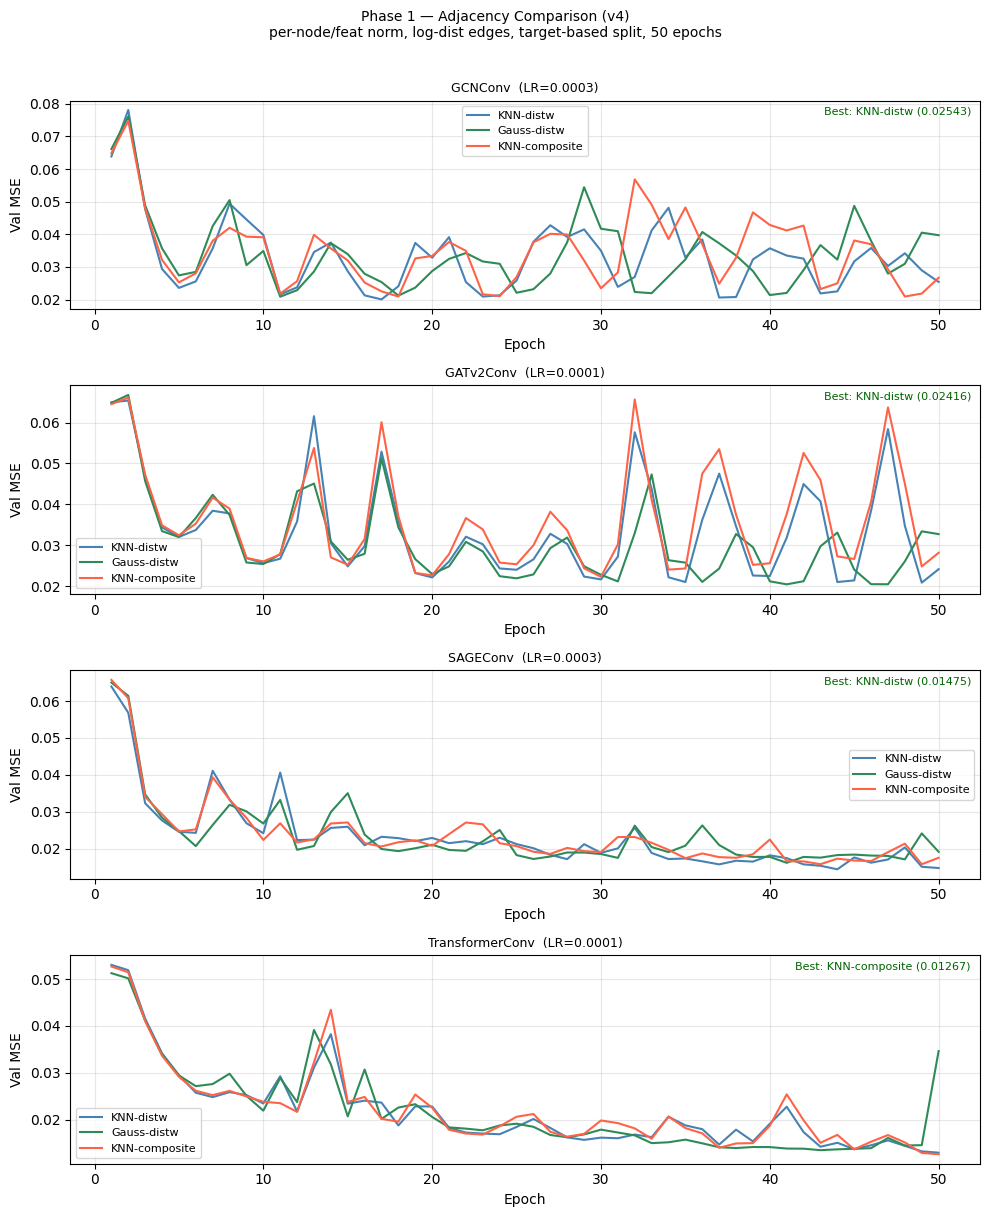

Saved: gnn_adjacency_comparison_v4.png


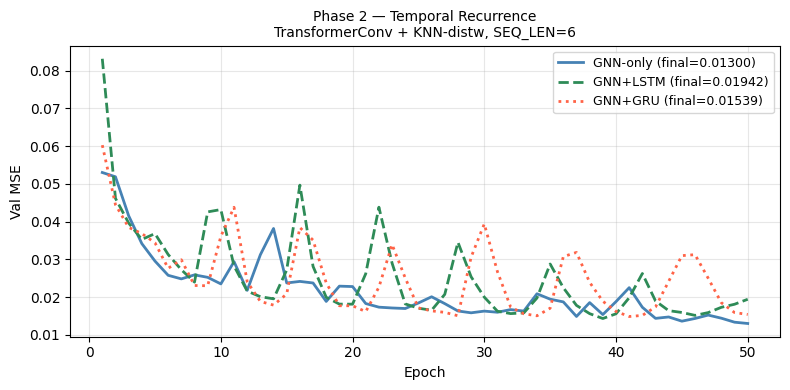

Saved: gnn_temporal_v4.png

── Detransformation demo (GNN-only best model, mid-val timestep) ──
  Predicting trade flows for: 2023-07  (702 valid edges)
  Edge (src→dst)          Pred (EUR M)    Actual (EUR M)     Rel err
  ──────────────────────────────────────────────────────────────────
  AT→BE                           376               422      11.03%
  AT→BG                         2,334               100    2233.79%
  AT→CY                            62                 5    1242.51%
  AT→CZ                           508               514       1.12%
  AT→DE                         3,086             4,880      36.76%
  AT→DK                            81                80       2.15%
  AT→EE                            57                17     236.40%
  AT→EL                           177                52     240.64%

  TARGET_SCALE used for detransform: 21.2947
  Formula: EUR = expm1(pred_scaled * TARGET_SCALE)
  ✓ Detransformation confirmed working


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell I — Results + Detransform Demo  (v4)
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.gridspec as gridspec

# ── I.1 Summary Table ─────────────────────────────────────────────────────────
print('\n' + '═' * 90)
print('  ADJACENCY COMPARISON — final val loss per architecture × adjacency method')
print('═' * 90)
header = f"{'Architecture':<20}" + ''.join(f'{n:>18}' for n in ADJ_METHODS)
print(header)
print('─' * 90)
for cls in ENCODER_CLASSES:
    name = cls.__name__
    row  = f'{name:<20}'
    for adj_name in ADJ_METHODS:
        val = adj_results[name][adj_name]
        best_flag = '*' if (name == best_arch_cls.__name__ and adj_name == best_adj_name) else ' '
        row += f'{val:>16.5f}{best_flag} '
    print(row)
print('═' * 90)
print(f'  * = best cell   Best adjacency: {best_adj_name}   Best arch: {best_arch_cls.__name__}')

print(f'\n  TEMPORAL RECURRENCE  (arch={best_arch_cls.__name__}, adj={best_adj_name})')
print(f"{'Model':<14}  {'Final val loss':>14}  {'vs GNN-only (log-ratio)':>24}")
print('─' * 58)
for label, hist in temporal_hists.items():
    score_str = '' if label == 'GNN-only' else f"{log_ratio_score(hist[-1], temporal_hists['GNN-only'][-1]):+.4f}"
    print(f'  {label:<12}  {hist[-1]:>14.5f}  {score_str:>24}')

# ── I.2 Adjacency val-loss curves (4 rows × 3 cols) ──────────────────────────
n_archs = len(ENCODER_CLASSES)
n_adjs  = len(ADJ_METHODS)
adj_names_list = list(ADJ_METHODS.keys())
colors   = ['steelblue', 'seagreen', 'tomato']

fig, axes = plt.subplots(n_archs, 1, figsize=(10, 3 * n_archs), squeeze=False)
ep = range(1, N_EPOCHS + 1)

for row, cls in enumerate(ENCODER_CLASSES):
    ax   = axes[row, 0]
    name = cls.__name__
    for col, (adj_name, color) in enumerate(zip(adj_names_list, colors)):
        hist = adj_hists[name][adj_name]
        ax.plot(ep, hist, label=adj_name, color=color, linewidth=1.5)
    ax.set_title(f'{name}  (LR={ARCH_LR[cls]})', fontsize=9)
    ax.set_ylabel('Val MSE')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    best_val = min(adj_results[name].values())
    best_adj = min(adj_results[name], key=adj_results[name].get)
    ax.text(0.99, 0.97, f'Best: {best_adj} ({best_val:.5f})',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            color='darkgreen')

plt.suptitle(
    f'Phase 1 — Adjacency Comparison (v4)\n'
    f'per-node/feat norm, log-dist edges, target-based split, {N_EPOCHS} epochs',
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.savefig('gnn_adjacency_comparison_v4.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: gnn_adjacency_comparison_v4.png')

# ── I.3 Temporal recurrence curves ────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 4))
t_colors  = {'GNN-only': 'steelblue', 'GNN+LSTM': 'seagreen', 'GNN+GRU': 'tomato'}
t_styles  = {'GNN-only': '-',         'GNN+LSTM': '--',        'GNN+GRU': ':'}
for label, hist in temporal_hists.items():
    ax2.plot(ep, hist, label=f'{label} (final={hist[-1]:.5f})',
             color=t_colors.get(label, 'gray'),
             linestyle=t_styles.get(label, '-'), linewidth=2)
ax2.set_title(
    f'Phase 2 — Temporal Recurrence\n'
    f'{best_arch_cls.__name__} + {best_adj_name}, SEQ_LEN={SEQ_LEN}',
    fontsize=10,
)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val MSE'); ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gnn_temporal_v4.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: gnn_temporal_v4.png')

# ── I.4 Detransformation demo ─────────────────────────────────────────────────
print('\n── Detransformation demo (GNN-only best model, mid-val timestep) ──')
best_gnn_model.eval()
t_demo = val_idx[len(val_idx) // 2]   # pick a middle validation timestep
ts_label = common_time[t_demo + 1].strftime('%Y-%m')

with torch.no_grad():
    x_demo    = node_feat_norm[t_demo].to(DEVICE)
    pred_sc   = best_gnn_model(x_demo, ei_best_d, ea_best_d, ei_pred_d, ea_pred_d).cpu()

pred_eur   = detransform(pred_sc)                    # → EUR trade flow space
actual_sc  = target_scaled[t_demo + 1]               # scaled actuals
actual_eur = detransform(actual_sc)                  # → EUR
valid_mask = ~torch.isnan(actual_eur).any(dim=-1)   # edges with non-NaN targets

print(f'  Predicting trade flows for: {ts_label}  ({valid_mask.sum().item()} valid edges)')
print(f'  {"Edge (src→dst)":<20}  {"Pred (EUR M)":>14}  {"Actual (EUR M)":>16}  {"Rel err":>10}')
print('  ' + '─' * 66)
shown = 0
for e_idx in range(len(edge_pairs)):
    if not valid_mask[e_idx]:
        continue
    src_c  = COUNTRIES[edge_pairs[e_idx][0]]
    dst_c  = COUNTRIES[edge_pairs[e_idx][1]]
    p_eur  = float(pred_eur[e_idx, 0]) / 1e6    # TOTAL category, in EUR millions
    a_eur  = float(actual_eur[e_idx, 0]) / 1e6
    rel_e  = abs(p_eur - a_eur) / (abs(a_eur) + 1e-6)
    print(f'  {src_c}→{dst_c:<16}  {p_eur:>14,.0f}  {a_eur:>16,.0f}  {rel_e:>10.2%}')
    shown += 1
    if shown >= 8:
        break

print(f'\n  TARGET_SCALE used for detransform: {TARGET_SCALE:.4f}')
print('  Formula: EUR = expm1(pred_scaled * TARGET_SCALE)')
print('  ✓ Detransformation confirmed working')


✓ Composite scores calculated for 702 edges.
New Adjacency Counts:
  KNN-distw       : 162 edges
  KNN-composite   : 162 edges
  Gauss-distw     : 350 edges
  Gauss-composite : 350 edges


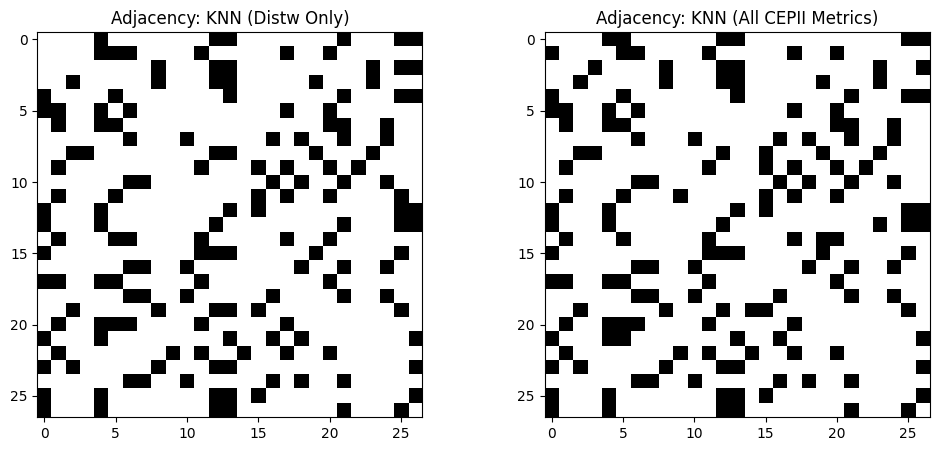

In [13]:
# =========================================================
# Additional Code: Compute Composite CEPII Similarity
# =========================================================

# Dictionary to store the mean similarity of all 7 CEPII metrics for each edge
composite_score = {}

for e_idx, (i, j) in enumerate(edge_pairs):
    # Use the normalized features [0, 1]
    vec = edge_feat_norm[e_idx].clone()
    
    # Flip distance-based features so: 1.0 = very close, 0.0 = very far
    # DISTANCE_FEAT_INDICES was defined in Cell D
    for col_idx in DISTANCE_FEAT_INDICES:
        vec[col_idx] = 1.0 - vec[col_idx]
    
    # Average all 7 metrics (3 binary/similarity + 4 inverted distances)
    # Resulting score: 1.0 = maximum similarity, 0.0 = minimum
    composite_score[(i, j)] = float(vec.mean())

print(f"✓ Composite scores calculated for {len(composite_score)} edges.")

# =========================================================
# Additional Code: KNN and Gauss for Distw vs. All Metrics
# =========================================================

K_VAL = 6  # neighbors

# --- 1. KNN by standard distance (distw) ---
knn_distw_pairs = []
for i in range(N):
    # Sort by distw (index 5 in CEPII_COLS) ascending
    by_dist = sorted([
        (edge_feat_map[(i, j)][5], j) 
        for j in range(N) if i != j and (i, j) in edge_feat_map
    ])[:K_VAL]
    knn_distw_pairs.extend([(i, j) for _, j in by_dist])

# --- 2. KNN by ALL metrics (Composite) ---
knn_composite_pairs = []
for i in range(N):
    # Sort by composite score descending (higher is better)
    by_score = sorted([
        (composite_score.get((i, j), -1.0), j) 
        for j in range(N) if i != j
    ], reverse=True)[:K_VAL]
    knn_composite_pairs.extend([(i, j) for _, j in by_score])

# --- 3. Gaussian by standard distance (distw) ---
all_distw = [edge_feat_map[(i, j)][5] for (i, j) in edge_pairs]
sigma_distw = float(np.median(all_distw)) / np.log(2)
gauss_distw_pairs = [
    (i, j) for (i, j) in edge_pairs
    if np.exp(-edge_feat_map[(i, j)][5] / sigma_distw) > 0.5
]

# --- 4. Gaussian by ALL metrics (Composite) ---
# For composite, we use the score directly. 
# threshold 0.5 means similarity better than median similarity
all_comp = list(composite_score.values())
threshold_comp = np.median(all_comp)
gauss_composite_pairs = [
    (i, j) for (i, j) in edge_pairs
    if composite_score.get((i, j), 0) > threshold_comp
]

# Update the global ADJ_METHODS dictionary for the sweep
ADJ_METHODS = {
    'KNN-distw': knn_distw_pairs,
    'KNN-composite': knn_composite_pairs,
    'Gauss-distw': gauss_distw_pairs,
    'Gauss-composite': gauss_composite_pairs
}

print("New Adjacency Counts:")
for name, pairs in ADJ_METHODS.items():
    print(f"  {name:<16}: {len(pairs)} edges")


def plot_adj_comparison(adj_a, name_a, adj_b, name_b):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    mat_a = np.zeros((N, N))
    for i, j in adj_a: mat_a[i, j] = 1
    ax1.imshow(mat_a, cmap='Greys')
    ax1.set_title(f"Adjacency: {name_a}")
    
    mat_b = np.zeros((N, N))
    for i, j in adj_b: mat_b[i, j] = 1
    ax2.imshow(mat_b, cmap='Greys')
    ax2.set_title(f"Adjacency: {name_b}")
    plt.show()

plot_adj_comparison(knn_distw_pairs, "KNN (Distw Only)", knn_composite_pairs, "KNN (All CEPII Metrics)")

In [14]:
# =========================================================
# Expanded Adjacency Construction (Multiple Methods)
# =========================================================

# Dictionary to hold the pairs for each specific method
EXP_ADJ_METHODS = {}

# 1. Only distw (K-Nearest)
EXP_ADJ_METHODS['KNN-distw'] = ADJ_METHODS['KNN-distw']

# 2. All and Average (K-Nearest by Composite Score)
EXP_ADJ_METHODS['KNN-composite'] = ADJ_METHODS['KNN-composite']

# 3. Similarity on everything (Gauss-Composite)
EXP_ADJ_METHODS['Gauss-composite'] = [
    (i, j) for (i, j) in edge_pairs
    if composite_score.get((i, j), 0) > np.median(list(composite_score.values()))
]

# 4. Different K (Example: K=12 for a denser graph)
K_DENSE = 12
knn_dense_pairs = []
for i in range(N):
    by_dist = sorted([(edge_feat_map[(i, j)][DISTW_COL], j) for j in range(N) if i != j])[:K_DENSE]
    knn_dense_pairs.extend([(i, j) for _, j in by_dist])
EXP_ADJ_METHODS[f'KNN-distw-k{K_DENSE}'] = knn_dense_pairs

# 5. Each CEPII variable separately (K-Nearest per metric)
for idx, col_name in enumerate(CEPII_COLS):
    sep_pairs = []
    is_dist = col_name in DISTANCE_FEAT_COLS
    for i in range(N):
        # If it's a distance, we want smallest. If it's similarity, we want largest.
        by_metric = sorted(
            [(edge_feat_map[(i, j)][idx], j) for j in range(N) if i != j],
            reverse=not is_dist 
        )[:K_NEIGHBORS]
        sep_pairs.extend([(i, j) for _, j in by_metric])
    EXP_ADJ_METHODS[f'Metric-{col_name}'] = sep_pairs

print(f"Constructed {len(EXP_ADJ_METHODS)} different adjacency methods for testing.")

Constructed 11 different adjacency methods for testing.


In [15]:
# =========================================================
# Benchmarking: Short Training Run
# =========================================================

SHORT_EPOCHS = 50
bench_results = []

print(f"{'Architecture':<16} | {'Adjacency Method':<20} | {'Final Val Loss':>14}")
print("-" * 56)

for cls in ENCODER_CLASSES:
    arch_name = cls.__name__
    lr = ARCH_LR[cls]
    
    for adj_name, pairs in EXP_ADJ_METHODS.items():
        # Build graph and run short train
        ei_mp, ea_mp = build_mp_graph(pairs, cls)
        hist = _train_loop(
            cls, ei_mp.to(DEVICE), ea_mp.to(DEVICE),
            edge_index_pred.to(DEVICE), edge_feat_norm.to(DEVICE),
            node_feat_norm, target_scaled, train_idx, val_idx,
            DEVICE, SHORT_EPOCHS, lr, SEED
        )
        
        final_loss = hist[-1]
        bench_results.append({
            'arch': arch_name,
            'method': adj_name,
            'val_loss': final_loss
        })
        print(f"{arch_name:<16} | {adj_name:<20} | {final_loss:14.6f}")

bench_df = pd.DataFrame(bench_results)

Architecture     | Adjacency Method     | Final Val Loss
--------------------------------------------------------
GCNConv          | KNN-distw            |       0.022783
GCNConv          | KNN-composite        |       0.035655
GCNConv          | Gauss-composite      |       0.021537
GCNConv          | KNN-distw-k12        |       0.022085
GCNConv          | Metric-comlang_ethno |       0.029381
GCNConv          | Metric-contig        |       0.024116
GCNConv          | Metric-smctry        |       0.021054
GCNConv          | Metric-dist          |       0.027768
GCNConv          | Metric-distcap       |       0.031211
GCNConv          | Metric-distw         |       0.026892
GCNConv          | Metric-distwces      |       0.030283
GATv2Conv        | KNN-distw            |       0.024150
GATv2Conv        | KNN-composite        |       0.029109
GATv2Conv        | Gauss-composite      |       0.037080
GATv2Conv        | KNN-distw-k12        |       0.026238
GATv2Conv        | Metric-comla

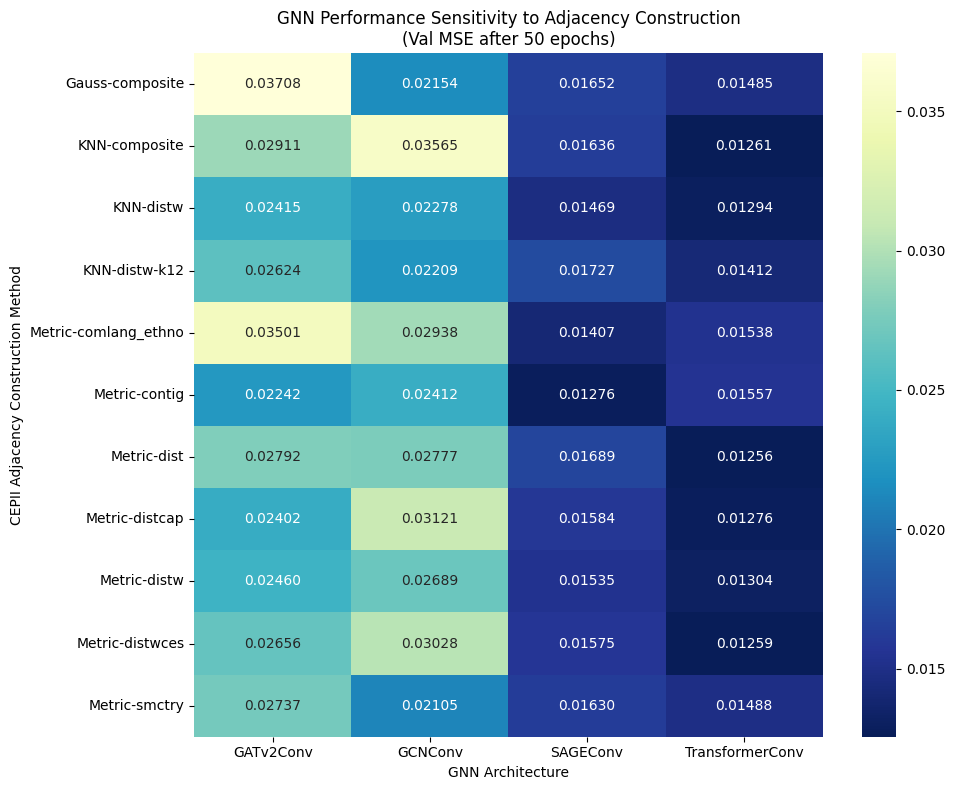

BEST PERFORMER: TransformerConv using Metric-dist (Loss: 0.012563)


In [16]:
# =========================================================
# Performance Variation Visualization
# =========================================================

import seaborn as sns

# Pivot data for heatmap
pivot_df = bench_df.pivot(index="method", columns="arch", values="val_loss")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt=".5f", cmap="YlGnBu_r")
plt.title(f"GNN Performance Sensitivity to Adjacency Construction\n(Val MSE after {SHORT_EPOCHS} epochs)")
plt.ylabel("CEPII Adjacency Construction Method")
plt.xlabel("GNN Architecture")
plt.tight_layout()
plt.show()

# Summary Recommendation
best = bench_df.loc[bench_df['val_loss'].idxmin()]
print(f"BEST PERFORMER: {best['arch']} using {best['method']} (Loss: {best['val_loss']:.6f})")